# Object detection on old maps


Goal is to detect buildings, both inhabited and un-inhabited from old maps and produce a GIS-layers of existing buildings for separate time-periods.

Further goal is then to analyze how the buildings have survived through the years.


The project was originally created in TensorFlow and Keras in 2023, now ported to pytorch-platform.

In [1]:
# Imports
import pandas as pd
import numpy as np
import os

In [ ]:
# TODO:
# Clean the code
# Check that column names are ok
# Check that class-id's start from 1 (0 is reserved for background class)
# Test the dataloader process
# Research for the different models; which can detect the location + class
# Also, which can "zoom" into the hierarchical structure & take surroundings also into account?
# How to handle the false positives, i.e. blocks that get detected as classes even if they are not that. Adding more background images?

## EDA to get the starting point right

In [ ]:
# Checking the label-files, which ones are the correct ones to use?
# ==>> annotations_extended_widenedby_3 is the latest and greatest, has 7 maps covered and 3 px buffer added to original bounding boxes

# File-naming: the original map has been slized into 256x256 px images. Naming follows either running number OR three-step naming "mymap_1_2_3". 
# Running-numbers: start from top-left corner, first downwards, then move one column to right. No overlap with neighboring images.
# Steps: Not sure about the logic, no overlap.



# test = pd.read_csv('data/annotations_2023-06-25_256px_annotations.csv') # 2,129, 332 uniq. images,  1 map, orig. width and height.
# test = pd.read_csv('data/annotations_extended_widenedby_1.csv') # 5,923, 962uniq-imgs, 6 maps, no widt/height specced.
# test = pd.read_csv('data/annotations_extended_widenedby_3.csv') # 7958, 1,298 uniq. imgs, 7 maps, no orig heights or widths
# test = pd.read_csv('data/extra_from_jan_256px_annotations.csv') # 2337, 435, 2 maps. has orig widths and heights BUT they are 5 different vals....
# test = pd.read_csv('data/train_256px_annotations_extended.csv') # 5,923, 962uniq-imgs,  6 maps, has orig widths and heights
# test = pd.read_csv('data/train_256px_annotations.csv') # 1457, 195, wxh = 1024 x 1024, 1 map


# NOTE:
# Correct version to use here (largest number of the images and already widened by 3 pixels)
# pd.read_csv('data/annotations_extended_widenedby_3.csv') 

# import re
# print(f"Nrows: {len(test)}")
# print(f"N unique images: {len(test.filename.unique())}")
# print(f"N unique maps: {list(set([re.match(r'.{11}', f_name).group() for f_name in test.filename]))}")
# try:
#     print(f"Unique width-vals: {test.width.unique()}")
#     print(f"Unique height-vals: {test.height.unique()}")
# except:
#     print("No width found in cols")
# test.head(n=3)

In [ ]:
# my_annotations = pd.read_csv('data/annotations_extended_widenedby_3.csv')
# my_annotations.head(n=10)
# # my_annotations = my_annotations.drop(['Unnamed: 0', 'width', "height"], axis=1)
# my_annotations['class_name'].value_counts()
# # pd.crosstab(index = my_annotations['filename'], columns = my_annotations['class_name'])


In [ ]:
# my_annotations['class_name'] = my_annotations['class_name'].map({'ulko': 'ulko', 'asuin': 'asuin', 'tpo': 'ulko', 
#                                                                  'rakennus_asumaton': 'ulko', 'rakennus_asuttu': 'asuin'})
# my_annotations['class_num'] = my_annotations['class_name'].map({'ulko': 1, 'asuin': 2}) # NOTE: Resercving the 0-class for the background-class
# print(my_annotations['class_name'].value_counts())
# my_annotations.head(n=20)


In [2]:
# DONE: Test if the labels are correctly mapped to the images (i.e. in correct locations) by visually plotting them

# importing required libraries
import matplotlib.pyplot as plt
import matplotlib.image as img
import matplotlib.patches as patches

def plot_bboxes_on_map(s_path):
    c_rows = my_annotations[my_annotations.filename == s_path]
    c_img = img.imread('data/images_train/' + s_path)

    # Create the axes
    my_fig, my_ax = plt.subplots(1)
    my_ax.imshow(c_img)
    plt.title(s_path)

    for c_ind, c_row in c_rows.iterrows():
        c_bbox = patches.Rectangle(xy=(my_annotations.xmin[c_ind],
                                my_annotations.ymin[c_ind]), 
                            width= my_annotations.xmax[c_ind] - my_annotations.xmin[c_ind], 
                            height= my_annotations.ymax[c_ind] - my_annotations.ymin[c_ind], 
                            edgecolor = "red", 
                            facecolor = "none")
        my_ax.add_patch(c_bbox)

    plt.show()





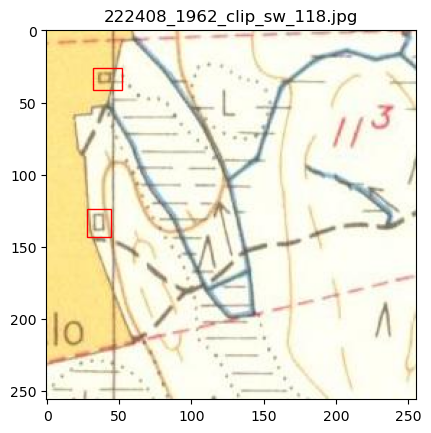

In [10]:
# Tested and works.
plot_bboxes_on_map(s_path = my_annotations.sample(n=1).filename.iloc[0])

In [ ]:
# Save the annotations in cleaned format, with combined classes to 2 and without extra cols.
# my_annotations.drop(columns=["Unnamed: 0"]).to_csv("data/train_256px_annotations_extended_cleaned_2026.csv", index=False)

In [3]:
my_annotations = pd.read_csv("data/train_256px_annotations_extended_cleaned_2026.csv")

Calculate the distribution of bbox-sizes; this will define the model-params (anchor and feature-network-pyramid scales)


==>> The median size for area is 250 px, with 25%-75% 170-290 px. Practical range is 80-800. With ratio of 1, these are 8x8 px (64), 13x13 (169), 16x16 (256), 17x17 (289) and 28x28 (784)  
==>> median for ratio is 1.05, practical range from 0.5 to 2

In [44]:
temp_my_annotations = my_annotations.copy()

temp_my_annotations['bbox_x'] = abs(temp_my_annotations.xmax - temp_my_annotations.xmin)
temp_my_annotations['bbox_y'] = abs(temp_my_annotations.ymax - temp_my_annotations.ymin)
temp_my_annotations['bbox_xy_ratio'] = temp_my_annotations.bbox_y / temp_my_annotations.bbox_x
temp_my_annotations['bbox_area'] = temp_my_annotations.bbox_x * temp_my_annotations.bbox_y
temp_my_annotations['bbox_area_sqrt'] = temp_my_annotations.bbox_area ** 0.5
temp_my_annotations['bbox_area_sqrt_class'] = pd.cut(temp_my_annotations['bbox_area_sqrt'], 
                                                     bins = [0, 10, 12, 14, 16,18, 20, 22, 24, 26, 28, 30, np.inf]) 
temp_my_annotations

,filename,class_name,xmin,ymin,xmax,ymax,class_num,bbox_x,bbox_y,bbox_xy_ratio,bbox_area,bbox_area_sqrt,bbox_area_sqrt_class
0,222112_1961_clean_0.jpg,ulko,159,197,173,213,1,14,16,1.142857,224,14.966630,"(14.0, 16.0]"
1,222112_1961_clean_0.jpg,ulko,113,212,133,228,1,20,16,0.800000,320,17.888544,"(16.0, 18.0]"
2,222112_1961_clean_0.jpg,ulko,159,179,171,192,1,12,13,1.083333,156,12.489996,"(12.0, 14.0]"
3,222112_1961_clean_0.jpg,ulko,151,184,162,196,1,11,12,1.090909,132,11.489125,"(10.0, 12.0]"
4,222112_1961_clean_1.jpg,ulko,149,108,163,120,1,14,12,0.857143,168,12.961481,"(12.0, 14.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7953,222109_1961_clean_565.jpg,ulko,7,145,20,156,1,13,11,0.846154,143,11.958261,"(10.0, 12.0]"
7954,222109_1961_clean_565.jpg,ulko,15,146,26,157,1,11,11,1.000000,121,11.000000,"(10.0, 12.0]"
7955,222109_1961_clean_565.jpg,asuin,6,173,22,190,2,16,17,1.062500,272,16.492423,"(16.0, 18.0]"
7956,222109_1961_clean_571.jpg,ulko,10,58,23,68,1,13,10,0.769231,130,11.401754,"(10.0, 12.0]"


count    7958.000000
mean      248.901985
std       114.118799
min        64.000000
25%       169.000000
50%       225.000000
75%       289.000000
max      1554.000000
Name: bbox_area, dtype: float64

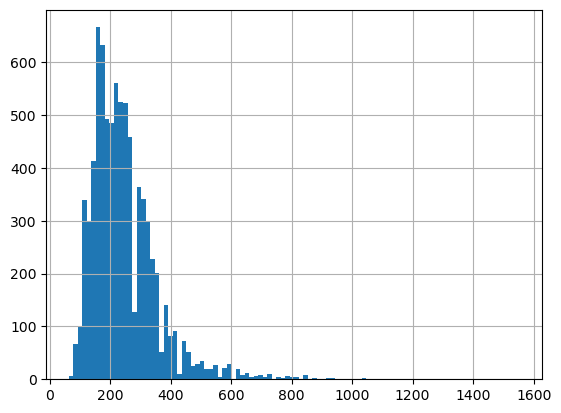

In [29]:
temp_my_annotations['bbox_area'].hist(bins = 100)
temp_my_annotations['bbox_area'].describe()

<Axes: xlabel='bbox_x', ylabel='bbox_y'>

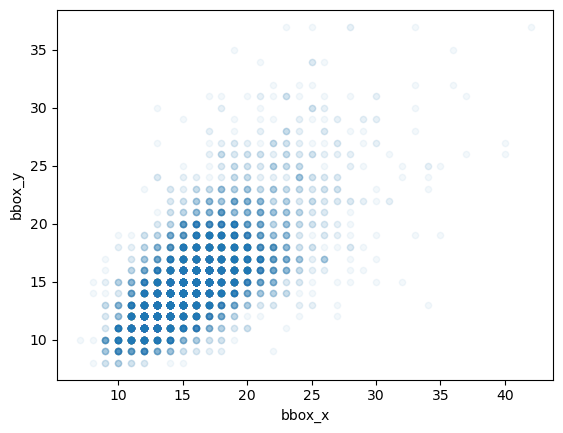

In [30]:
temp_my_annotations.plot.scatter(x = 'bbox_x', y = 'bbox_y', alpha = 0.05)

count    7958.000000
mean        0.964361
std         0.170556
min         0.382353
25%         0.851852
50%         0.937500
75%         1.062500
max         2.307692
Name: bbox_xy_ratio, dtype: float64

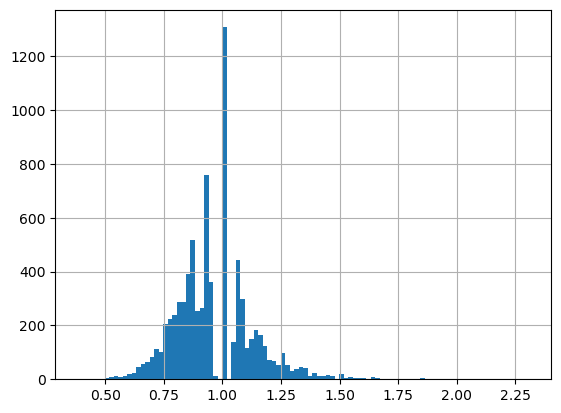

In [45]:
temp_my_annotations['bbox_xy_ratio'].hist(bins = 100)
temp_my_annotations['bbox_xy_ratio'].describe()

In [19]:
temp_my_annotations

,filename,class_name,xmin,ymin,xmax,ymax,class_num,bbox_x,bbox_y,bbox_xy_ratio,bbox_area
0,222112_1961_clean_0.jpg,ulko,159,197,173,213,1,14,16,0.875000,224
1,222112_1961_clean_0.jpg,ulko,113,212,133,228,1,20,16,1.250000,320
2,222112_1961_clean_0.jpg,ulko,159,179,171,192,1,12,13,0.923077,156
3,222112_1961_clean_0.jpg,ulko,151,184,162,196,1,11,12,0.916667,132
4,222112_1961_clean_1.jpg,ulko,149,108,163,120,1,14,12,1.166667,168
...,...,...,...,...,...,...,...,...,...,...,...
7953,222109_1961_clean_565.jpg,ulko,7,145,20,156,1,13,11,1.181818,143
7954,222109_1961_clean_565.jpg,ulko,15,146,26,157,1,11,11,1.000000,121
7955,222109_1961_clean_565.jpg,asuin,6,173,22,190,2,16,17,0.941176,272
7956,222109_1961_clean_571.jpg,ulko,10,58,23,68,1,13,10,1.300000,130


In [52]:
temp_my_annotations

,filename,class_name,xmin,ymin,xmax,ymax,class_num,bbox_x,bbox_y,bbox_xy_ratio,bbox_area,bbox_area_sqrt,bbox_area_sqrt_class
0,222112_1961_clean_0.jpg,ulko,159,197,173,213,1,14,16,1.142857,224,14.966630,"(14.0, 16.0]"
1,222112_1961_clean_0.jpg,ulko,113,212,133,228,1,20,16,0.800000,320,17.888544,"(16.0, 18.0]"
2,222112_1961_clean_0.jpg,ulko,159,179,171,192,1,12,13,1.083333,156,12.489996,"(12.0, 14.0]"
3,222112_1961_clean_0.jpg,ulko,151,184,162,196,1,11,12,1.090909,132,11.489125,"(10.0, 12.0]"
4,222112_1961_clean_1.jpg,ulko,149,108,163,120,1,14,12,0.857143,168,12.961481,"(12.0, 14.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7953,222109_1961_clean_565.jpg,ulko,7,145,20,156,1,13,11,0.846154,143,11.958261,"(10.0, 12.0]"
7954,222109_1961_clean_565.jpg,ulko,15,146,26,157,1,11,11,1.000000,121,11.000000,"(10.0, 12.0]"
7955,222109_1961_clean_565.jpg,asuin,6,173,22,190,2,16,17,1.062500,272,16.492423,"(16.0, 18.0]"
7956,222109_1961_clean_571.jpg,ulko,10,58,23,68,1,13,10,0.769231,130,11.401754,"(10.0, 12.0]"


/tmp/ipykernel_12213/885595536.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  koe_boxplot = temp_my_annotations.groupby('bbox_area_sqrt_class').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 10), rot = 90)


(0.5, 1.5)

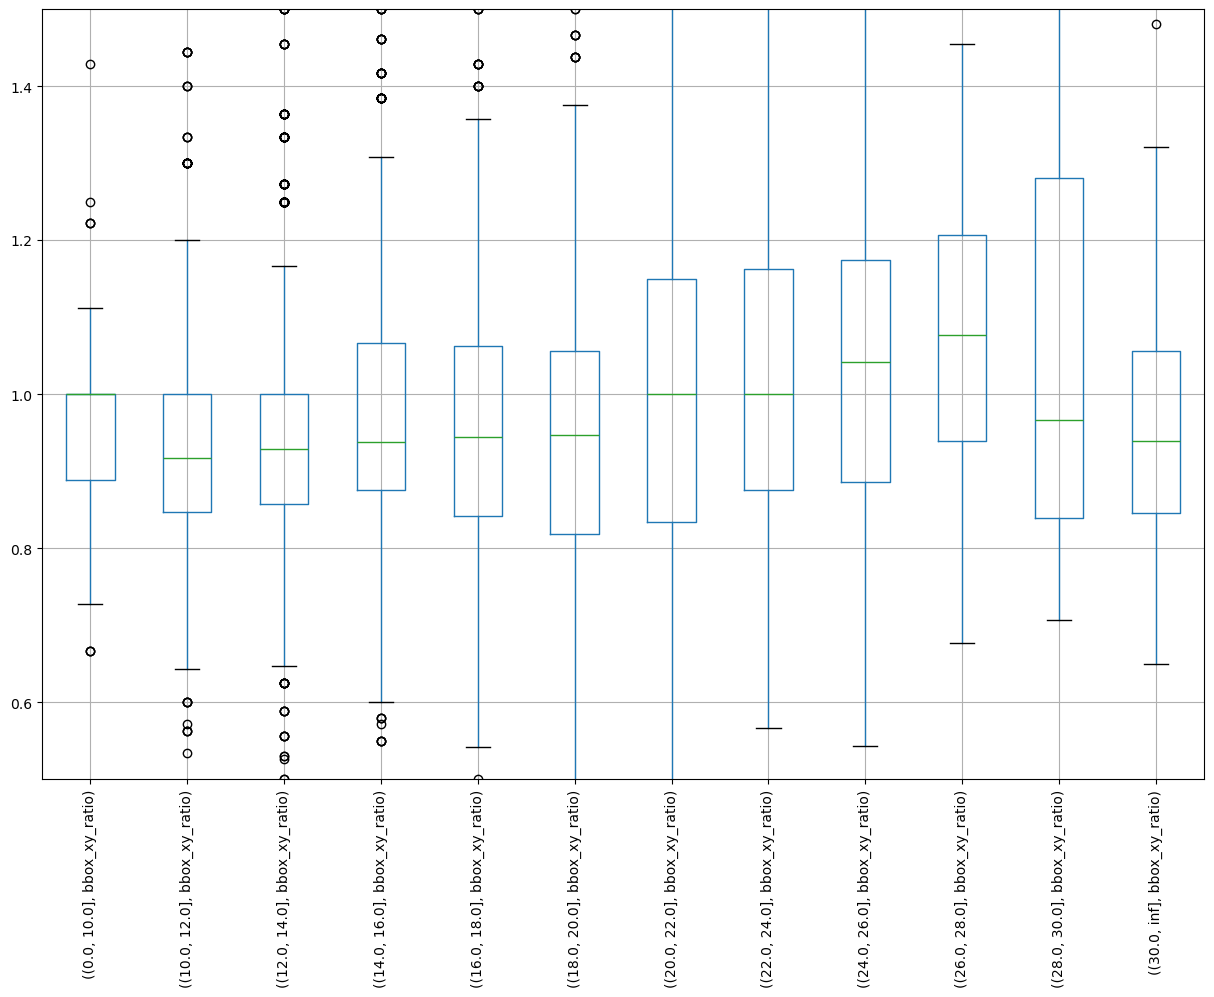

In [ ]:
# Plot the ratios for each size-category 
# temp_my_annotations.groupby('bbox_area_sqrt_class').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 10), rot = 90)

koe_boxplot = temp_my_annotations.groupby('bbox_area_sqrt_class').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 10), rot = 90)
koe_boxplot.set_ylim([0.5, 1.5])
# ax = df.plot(kind='box', ylim=(-5, 5))
# ax = df.plot(kind='box', yticks=range(-5, 6))
# boxplot = prices.boxplot(column=['price'])
# boxplot.set_xlim([xmin, xmax])
# boxplot.set_ylim([ymin, ymax])

In [59]:
def q10p(x):
    return x.quantile(0.1)

def q20p(x):
    return x.quantile(0.2)

def q50p(x):
    return x.quantile(0.5)

def q80p(x):
    return x.quantile(0.8)

def q90p(x):
    return x.quantile(0.9)

temp_my_annotations.groupby('bbox_area_sqrt_class').agg({'bbox_xy_ratio': [q10p, q20p, q50p, q80p, q90p]})

/tmp/ipykernel_12213/13070678.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_my_annotations.groupby('bbox_area_sqrt_class').agg({'bbox_xy_ratio': [q10p, q20p, q50p, q80p, q90p]})


bbox_xy_ratio                                        
                              q10p      q20p      q50p      q80p      q90p
bbox_area_sqrt_class                                                      
(0.0, 10.0]               0.818182  0.818182  1.000000  1.000000  1.111111
(10.0, 12.0]              0.769231  0.833333  0.916667  1.000000  1.100000
(12.0, 14.0]              0.785714  0.857143  0.928571  1.076923  1.153846
(14.0, 16.0]              0.777778  0.823529  0.937500  1.071429  1.142857
(16.0, 18.0]              0.789474  0.833333  0.944444  1.117647  1.200000
(18.0, 20.0]              0.739130  0.809524  0.947368  1.111111  1.222222
(20.0, 22.0]              0.708333  0.826087  1.000000  1.157895  1.277778
(22.0, 24.0]              0.734758  0.840000  1.000000  1.238095  1.361053
(24.0, 26.0]              0.785714  0.864957  1.041667  1.217391  1.322727
(26.0, 28.0]              0.776207  0.928571  1.076923  1.275000  1.347826
(28.0, 30.0]              0.735294  0.781250  0.966667  1.307692  1.360000
(30.0, inf]               0.688851  0.837838  0.939394  1.121212  1.321429

<Axes: >

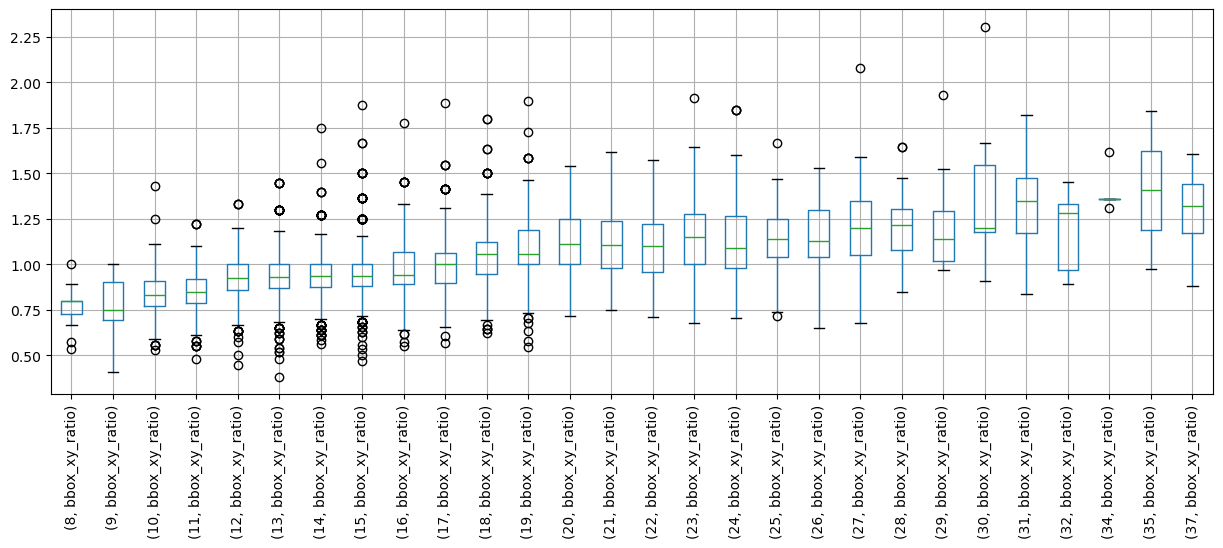

In [33]:
temp_my_annotations.groupby('bbox_y').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 5), rot = 90)

<Axes: >

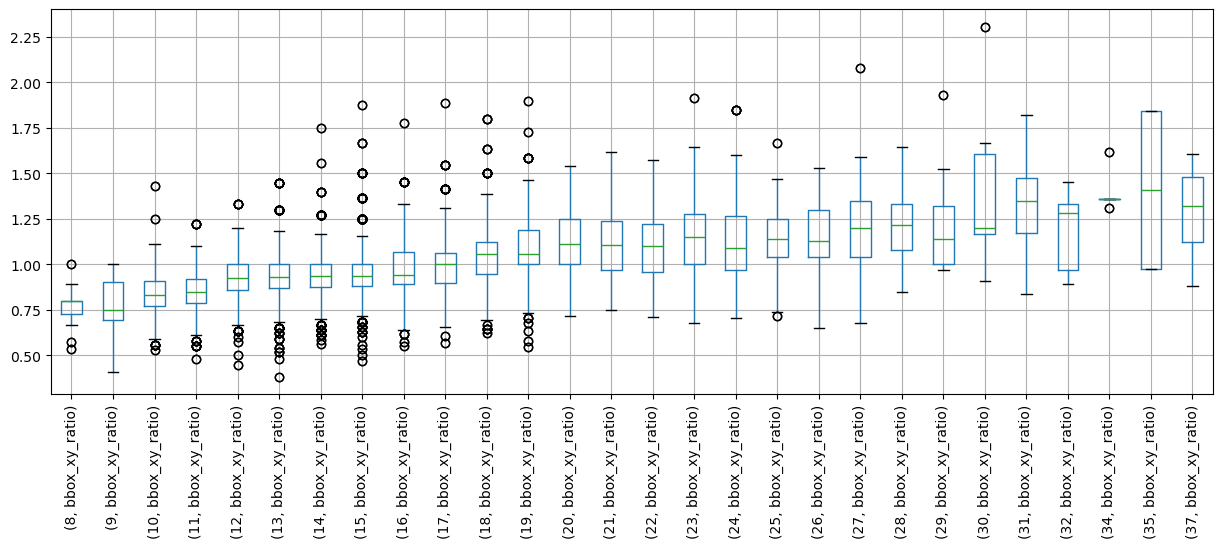

In [41]:
# temp_my_annotations.groupby('bbox_y').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 5), rot = 90)

koe = pd.concat([temp_my_annotations, temp_my_annotations], axis = 0).reset_index()
koe.groupby('bbox_y').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 5), rot = 90)

<Axes: xlabel='bbox_xy_ratio', ylabel='bbox_area'>

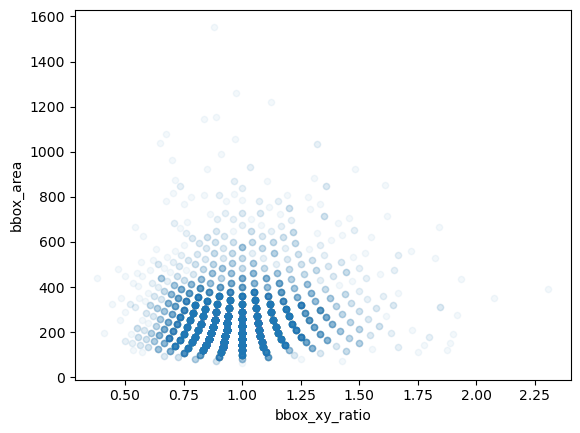

In [34]:
# temp_my_annotations.groupby('bbox_y').boxplot(subplots=False, column = 'bbox_xy_ratio', figsize = (15, 5), rot = 90)
temp_my_annotations.plot.scatter(x = 'bbox_xy_ratio', y = 'bbox_area', alpha = 0.05)

count    1298.000000
mean        6.130971
std         5.855345
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        41.000000
dtype: float64
--------------------
26.029999999999973


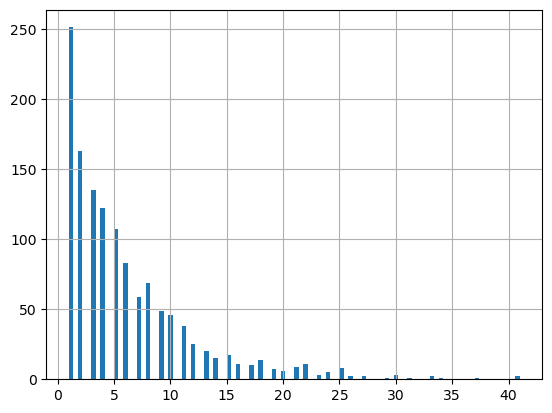

In [22]:
# Distrubution of the number of boxes per image
# ==>> 1,300 unique images
# 50% have 4 or less boxes in them (min is 1, so each image has at least one bbox)
# Max is 41, but practical max (99th percentile) is 26
temp_my_annotations.groupby('filename').size().hist(bins=100)
print(temp_my_annotations.groupby('filename').size().describe())
print("-"*20)
print(temp_my_annotations.groupby('filename').size().quantile(0.99))

# Old version from Keras

In [ ]:
## images
my_imgs_all = []  # 195 images total that DO HAVE labels / annotations
for c_name in my_annotations.filename.unique():
    c_img = keras.preprocessing.image.load_img(os.path.join('F:/Projects/TFOD_23/crops/train_256px_extended/', c_name), 
                                               target_size=(256, 256))
    c_img = np.asarray(c_img).astype('float32')
    my_imgs_all.append(c_img)
    
del c_name, c_img

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sun May 28 21:49:56 2023

@author: Late

Model version 3
now the training-images are in 256x256 crops, to help the model
(as object covers more of the image area)

"""

## imports
import tensorflow as tf
from tensorflow import keras
import keras_cv
from keras_cv import bounding_box
from keras_cv import visualization
import numpy as np
import pandas as pd
import os
import tqdm ## needed for custom callback function


## initial values
my_batch_size = 56




## helper functions
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format = "xyxy", in_scale = 10, plot_preds = False, model = None, print_rng = False):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
    if plot_preds:
        bbox_pred = model.predict(images)
        if print_rng:
            if bbox_pred["num_detections"].any() > 0:
                print("range in pred confidence; " + str(np.ptp(bbox_pred["confidence"].values)))
            else:
                print("No detections")
    else:
        bbox_pred = None
    visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        y_pred = bbox_pred,
        scale=in_scale,
        font_scale=0.5,
        line_thickness = 1,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )
    

    
## Custom callback function for evaluation metrics;
## should be needed only for the TPU-compatibility (?)
class EvaluateCOCOMetricsCallback(keras.callbacks.Callback):
    def __init__(self, data):
        super().__init__()
        self.data = data
        self.metrics = keras_cv.metrics.BoxCOCOMetrics(
            bounding_box_format="xyxy",
            # passing 1e9 ensures we never evaluate until
            # `metrics.result(force=True)` is
            # called.
            evaluate_freq=1e9,
        )

    def on_epoch_end(self, epoch, logs):
        self.metrics.reset_state()
        for batch in tqdm.tqdm(self.data):
            # images, y_true = batch[0], batch[1]
            images, y_true = (batch["images"], batch["bounding_boxes"]["boxes"])
            y_pred = self.model.predict(images, verbose=0)
            y_pred = keras_cv.bounding_box.to_dense(y_pred, max_boxes=my_max_boxes) ## Note my_max_boxes from env! added from https://github.com/keras-team/keras-cv/issues/1795
            print(y_true)
            print(y_pred)
            # TODO; find the correct format; https://keras.io/guides/keras_cv/coco_metrics/
            # TODO2; 
            self.metrics.update_state(y_true, y_pred)

        metrics = self.metrics.result(force=True)
        print(metrics)
        logs.update(metrics)
        return logs


## TODO; above on_epoch_end;
 # Args:
 #      groundtruth_data: Groundtruth annotations in a tensor with each row
 #        representing [y1, x1, y2, x2, is_crowd, area, class].
 #      detections: Detection results in a tensor with each row representing
 #        [image_id, x, y, width, height, score, class].




class VisualizeEval(keras.callbacks.Callback):
    def __init__(self, epoch):
        super().__init__()
        self.epoch = epoch
        self.model = model
    def on_epoch_end(self, epoch, logs):
        visualize_dataset(inputs = my_data_eval, value_range = (0, 255), rows = 1, cols = 2, 
                          bounding_box_format= "xyxy", plot_preds=True, model = self.model, print_rng = True)
        print("predictions plotted on epoch:", epoch)



## callbacks for tensorboard to monitor the training + saving model checkpoints
my_tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="F:/Projects/TFOD_23/temp/logs")

## NOTE; cannot be in same "temp" folder than the above callback, but one step up (+new folder) in  folder hierarchy
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="F:/Projects/TFOD_23/temp2/model_checkpoints_{epoch:02d}",
    save_weights_only=False,
    monitor='val_box_loss',
    mode='min',
    save_best_only=False,
    save_freq = 5*my_batch_size) ## saves every 5 epochs



## import annotations and image data

## annotations
# my_annotations = pd.read_csv('F:/Projects/TFOD_23/crops/train_256px/train_256px_annotations.csv') ## annotations now already in csv
my_annotations = pd.read_csv('F:/Projects/TFOD_23/crops/train_256px_extended/train_256px_annotations_extended.csv') ## annotations now already in csv
my_annotations = pd.read_csv('F:/Projects/TFOD_23/crops/train_256px_extended/annotations_extended_widenedby_3.csv')

my_annotations = my_annotations.drop(['Unnamed: 0', 'width', "height"], axis=1)
my_annotations = my_annotations.drop(['Unnamed: 0'], axis=1)
my_annotations.head(20)

my_annotations['class_name'].value_counts()
pd.crosstab(index = my_annotations['filename'], columns = my_annotations['class_name'])
## add numeric class based on the "class_name" and format class_mapping -dictionary
## temp; test if converting "tpo" class to 0 ("ulko") changes model converging?
## Also change labels to same format
my_annotations['class_name'] = my_annotations['class_name'].map({'ulko': 'ulko', 'asuin': 'asuin', 'tpo': 'ulko', 
                                                                 'rakennus_asumaton': 'ulko', 'rakennus_asuttu': 'asuin'})
my_annotations['class_num'] = my_annotations['class_name'].map({'ulko': 0, 'asuin': 1, 'tpo': 0, })
class_mapping = dict(zip(range(len(["ulko", "asuin"])), ["ulko", "asuin"]))
## original numeric conversion;
# my_annotations['class_num'] = my_annotations['class_name'].map({'ulko': 0, 'asuin': 1, 'tpo': 2})
# class_mapping = dict(zip(range(len(["ulko", "asuin", "tpo"])), ["ulko", "asuin", "tpo"]))

## remove some rows that only have single building in them; (hopefully preventing "Nan loss" problem...)
# koe = my_annotations.groupby(['filename'])['filename'].count().reset_index(name='blaa')
# koe = koe.set_index('filename')
# koe2 = my_annotations.join(other = koe, on = 'filename', how = 'left')
# koe2.head(30)
# koe2.blaa.value_counts()
# my_annotations = koe2[koe2.blaa > 1].copy()
# my_annotations.head(10)

## ensure the annotations-df is sorted by filename; otherwise the labels will locate to wrong image!
my_annotations = my_annotations.sort_values(by=['filename'])

## extract the classes and bbox by each filename
my_annotations_grp = my_annotations.groupby('filename') # Group the DataFrame by the 'filename' column

# Create empty lists to store the bounding box coordinates and class names
boxes_list = []
classes_list = []

# Iterate over each group
for _, grp in my_annotations_grp:
    # Get the bounding box coordinates and class names for the current image
    boxes_temp = grp[['xmin', 'ymin', 'xmax', 'ymax']].values
    classes_temp = grp['class_num'].values
    
    # Append the bounding box coordinates and class names to the respective lists
    boxes_list.append(boxes_temp)
    classes_list.append(classes_temp)

## remove un-needed variables
del boxes_temp, classes_temp, grp

## Convert to numpy arrays
## use list comprehension as each image has different number of bboxes (default "np.array(my_list)" works onl if each img has same number of bboxes)
## note the use of "float32" conversion as that is needed by tf
boxes_list = np.array([np.array(b, dtype=np.float32) for b in boxes_list])
classes_list = np.array([np.array(c, dtype=np.float32) for c in classes_list])


## convert to tensors; note that shape is automatically detected, resulting in (10, None, None) and (10, none)
## ==> Transforming to dense matrix fixes this
boxes_tensor = tf.ragged.constant(boxes_list)
classes_tensor = tf.ragged.constant(classes_list)
# boxes_tensor.shape ## shape (10, None, None) --> will be fixed with "to_dense"-function later
# classes_tensor.shape

my_annotations_dict = {
    "boxes":boxes_tensor,
    "classes":classes_tensor 
    }

## How many boxes are need at maximum?
my_max_boxes = my_annotations['filename'].value_counts().max() ## 41 is maximum at 2023-06-04 (256px edition)

my_annotations_dict_dense = bounding_box.to_dense(my_annotations_dict, max_boxes=my_max_boxes) ## Observed maximum for the data
# my_annotations_dict_dense["boxes"].shape ## shape now corrected to (num_images, num_boxes, box_coords)
# my_annotations_dict_dense["boxes"][0] ## seems to provide meaningful results
## Testing the conversion; NOTE THAT the "-1" values that are filled to dense format are wrongly converted to "-0.00097..."!!!
# my_annotations_dict_rel = bounding_box.convert_format(my_annotations_dict_dense, source = "xyxy", target = "rel_xyxy", image_shape=(1024, 1024, 3))
# my_annotations_dict_rel["boxes"][0] ## Wrongly converted "-1" ==>> Do not use!
len(my_annotations.filename.unique())

## images
my_imgs_all = []  # 195 images total that DO HAVE labels / annotations
for c_name in my_annotations.filename.unique():
    c_img = keras.preprocessing.image.load_img(os.path.join('F:/Projects/TFOD_23/crops/train_256px_extended/', c_name), 
                                               target_size=(256, 256))
    c_img = np.asarray(c_img).astype('float32')
    my_imgs_all.append(c_img)
    
del c_name, c_img

my_imgs_tensor = tf.constant(my_imgs_all) ## works as all images are of same size!
my_imgs_tensor.shape ## image-tensor's shape is correct right from the start (10, 1024, 1024, 3)

## combine annotations and images
## using dict (instead of tuple) is needed to enable data augmentation
my_data = {"images": my_imgs_tensor, "bounding_boxes": my_annotations_dict_dense}
my_data = tf.data.Dataset.from_tensor_slices(my_data)
# visualize_dataset(inputs = my_data.ragged_batch(10), value_range = (0, 255), rows = 2, cols = 5)
# my_data = my_data.shuffle(20) # NOTE; Shuffling here pushes / iterates ALL images to eval & train sets!!


## splitting dataset for training and evaluation from shuffled dataset
my_data_train = my_data.take(560) #
my_data_eval = my_data.skip(560) # 

my_data_train = my_data_train.shuffle(560)
# my_data_eval = my_data_eval.shuffle(70)

my_batch_size = 56
my_data_train = my_data_train.ragged_batch(my_batch_size)
my_data_eval = my_data_eval.ragged_batch(70)
## image augmentation for training data
# my_augmenter = keras.Sequential(
#     layers=[
#         keras_cv.layers.RandomFlip(mode="horizontal_and_vertical", bounding_box_format="xyxy"),
#         keras_cv.layers.RandomCrop(height = 640, width = 640, bounding_box_format = "xyxy"),
#         # keras_cv.layers.Resizing(height = 1024, width = 1024, bounding_box_format="xyxy", pad_to_aspect_ratio=True)
#         # Resizing does not work after the randomCrop, error: ValueError: Tensor's shape (1, 0, 0) is not compatible with supplied shape (1, None, 4).
#         ## ONE OPTION: crop only to 512 x 512 and use that size for predictions also....
#     ]
# )

## flip + rotation, with 0.3*360 degrees rotation range
## Note that when rotating, the corners are clipped, and image scale / resolution remains the same
##      ==> boxes in corners might be missing from some augmentation runs.
## Note also that while boxes are relocated to correct loc, they are not rotated, 
##      i.e. might be a problem with elongated objects?
# my_augmenter = keras.Sequential(
#     layers=[
#         keras_cv.layers.RandomFlip(mode="horizontal_and_vertical", bounding_box_format="xyxy"),
#         keras_cv.layers.RandomRotation(factor = 0.3, fill_mode="constant", interpolation="bilinear", fill_value=255, bounding_box_format="xyxy"
#         )
#     ]
# )

## Test augmenting by flipping + smaller rotation, so that bounding boxes do not clip the corners of buildings
# factor 0.03 = 11 degrees
# my_augmenter = keras.Sequential(
#     layers=[
#         keras_cv.layers.RandomFlip(mode="horizontal_and_vertical", bounding_box_format="xyxy"),
#         keras_cv.layers.RandomRotation(factor = 0.03, fill_mode="constant", interpolation="bilinear", fill_value=255, bounding_box_format="xyxy"
#         )
#     ]
# )

my_augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(mode="horizontal_and_vertical", bounding_box_format="xyxy"),
        keras_cv.layers.RandomRotation(factor = 0.1, fill_mode="constant", interpolation="bilinear", fill_value=255, bounding_box_format="xyxy"
        )
        #,
        # keras_cv.layers.RandomChannelShift(value_range = (0, 255), factor = (0, 1), channels=3),
        # keras_cv.layers.MixUp(alpha=0.2)
        # keras_cv.layers.ChannelShuffle(groups=3)
        # keras_cv.layers.RandomSharpness(factor = (0.9, 1), value_range = (0, 255))
        # keras_cv.layers.RandomShear(x_factor= (0, 0.2), y_factor= (0, 0.2), interpolation="bilinear", 
        #                             fill_mode="constant", fill_value=255, bounding_box_format="xyxy")
    ]
)

## Below augmentation gives warning but works and seems that bboxes are correctly translated
## NOTE; mapping augmenter to dataset does not over-write earlier augmentation, just adds to it!
my_data_train = my_data_train.map(my_augmenter, num_parallel_calls=tf.data.AUTOTUNE)
# my_data_train = my_data_train.map(my_augmenter2, num_parallel_calls=tf.data.AUTOTUNE)
# next(iter(my_data_train.take(1)))["images"].shape
# next(iter(my_data_train.take(1)))["bounding_boxes"]["boxes"].shape ## boxes have 
# shape (2, None, 4) as num of boxes is now ragged via them being outside of the remaining window when roatetd

## check augmented images
visualize_dataset(
    my_data_train, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=4, plot_preds = False, model = None
)


my_data_train = my_data_train.prefetch(tf.data.AUTOTUNE) ## changes data to _PrefetchDataset
my_data_eval = my_data_eval.prefetch(tf.data.AUTOTUNE)

## Define optimizer
# including a global_clipnorm is extremely important in object detection tasks
# my_optimizer = tf.keras.optimizers.SGD(
#     learning_rate=0.005, momentum=0.9, global_clipnorm=10.0
# )
# for best results, a hand-crafted PiecewiseConstantDecay -learning-rate schedule would be best
## TESTING; would Adam optimizer with epsilon-addition (i.e. ensures that no gradient goes to 0)
# my_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001, global_clipnorm=5.0, clipvalue = 1)
my_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0005, global_clipnorm=5.0, clipvalue = 1)

###### Model
## using pretrained ResNet50 backbone
# The RetinaNet accepts tuples of dense image Tensors and bounding box 
# dictionaries to fit() and train_on_batch()
# ORIGINAL = "resnet50_imagenet"
# custom test = "yolo_v8_m_pascalvoc" (this has weights already in place, should be good-to-go for direct predictions)
# model = keras_cv.models.RetinaNet.from_preset(
#     "resnet50_imagenet",
#     num_classes=len(class_mapping),
#     bounding_box_format="xyxy",
#     load_weights=True ## added to test if model learns....
# )
# print(model.summary()) ## trainable params 35m

## Version; build from scratch
## Edition 1; low amont of filters
my_backbone = keras_cv.models.ResNetBackbone(
    stackwise_filters=[16, 32, 64, 128], ## setting lower amount of filters; orig: 64-128-526-512
    stackwise_blocks=[2, 2, 2, 2],
    stackwise_strides=[1, 2, 2, 2],
    include_rescaling=True,
)
my_backbone = keras_cv.models.ResNetBackbone( ## mid-level version
    stackwise_filters=[32, 64, 128, 256], ## setting lower amount of filters; orig: 64-128-526-512
    stackwise_blocks=[2, 2, 2, 2],
    stackwise_strides=[1, 2, 2, 2],
    include_rescaling=True,
)
my_backbone = keras_cv.models.ResNetBackbone( ## mid-level version
    stackwise_filters=[64, 128, 256, 512], ## setting lower amount of filters; orig: 64-128-526-512
    stackwise_blocks=[2, 2, 2, 2],
    stackwise_strides=[1, 2, 2, 2],
    include_rescaling=True,
)
model = keras_cv.models.RetinaNet(
    backbone=my_backbone,
    num_classes=len(class_mapping),
    bounding_box_format="xyxy",
)
print(model.summary()) ## trainable params 8m




## set / test model internal parameters
model.backbone.trainable
my_max_boxes
my_pred_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xyxy",
    from_logits=True,
    iou_threshold=0.5,
    confidence_threshold=0.05, ## low treshold to see how predictions advance
    max_detections= 40, # my_max_boxes + ~ 10. orig. treshold = 100
    max_detections_per_class=40
)
model.prediction_decoder = my_pred_decoder

## get weights from previous run;
## NOTE; only possible if the model structure is exactly same, ie. same stackwise_fitlers etc...
model.get_weights()
model.load_weights(
    "F:/Projects/TFOD_23/model_saves/save_2023-06-11-1040/model_checkpoints_293")

## compile
model.compile(
    classification_loss="focal",
    box_loss="smoothl1",
    optimizer=my_optimizer,
    # metrics = [coco_metrics] ## from pycocotools-library
    metrics=None # this is to use our custom callback to evaluate COCO metrics
)


############  Yolo - section
## Custom configuration for YOLO-model instead
## Note that the metrics and compilation with losses etc do not work directly...
# model = keras_cv.models.YOLOV8Detector.from_preset( 
#     "yolo_v8_m_pascalvoc",
#     # num_classes=len(class_mapping),
#     bounding_box_format="xyxy",
#     load_weights=True
# )

# model = keras_cv.models.YOLOV8Detector(
#     num_classes=2,
#     bounding_box_format="xyxy",
#     backbone=keras_cv.models.YOLOV8Backbone.from_preset(
#         "yolo_v8_m_backbone"
#     ),
#     fpn_depth=2
# )

# ## compile
# model.compile(
#     classification_loss="binary_crossentropy",
#     box_loss="iou",
#     optimizer=my_optimizer,
#     # metrics = [coco_metrics] ## from pycocotools-library
#     metrics=None # this is to use our custom callback to evaluate COCO metrics
# )

################ Yolo section end


## fit
model.fit(
    my_data_train,
    validation_data=my_data_eval,
    epochs=200,
    #callbacks=[EvaluateCOCOMetricsCallback(my_data_eval)]
    callbacks = [VisualizeEval(model), my_tensorboard_callback, model_checkpoint_callback]
)

## test model saving options; do all of the versions work and save the needed cutom layers etc?
model.save(filepath= "F:/Projects/TFOD_23/model_saves/testmodel_2023-06-08_keras_xt2.keras", 
           save_format = "keras", include_optimizer = True, save_traces = True)
model.save(filepath= "F:/Projects/TFOD_23/model_saves/testmodel_2023-06-08_tf_xt2.tf", 
           save_format = "tf", include_optimizer = True, save_traces = True)  ## TypeError: bad argument type for built-in operation
model.save(filepath= "F:/Projects/TFOD_23/model_saves/testmodel_2023-06-08_hdf5_xt2.h5", 
           save_format = "h5", include_optimizer = True, save_traces = True)

## save weights
model.save_weights(filepath= "F:/Projects/TFOD_23/model_saves/testmodel_2023-06-10_weightsonly.tf", 
                   save_format= "tf")


## load weights from earlier iteration
model.get_weights()
model.load_weights("F:/Projects/TFOD_23/model_saves/save_2023-06-10-1930/model_checkpoints_173")


# model loading not working; error "ValueError: Unknown layer: 'RetinaNet'"
## testing if loading weights is possible above
# model = tf.keras.saving.load_model("F:/Projects/TFOD_23/model_saves/testmodel_2023-06-02.keras")
##

## Launch tensorboard from new anaconda prompt: 
# tensorboard --logdir="F:/Projects/TFOD_23/temp/logs"

## PROBLEM 2023-06-01; "loss: nan"
## Tried the following;
#       1) change optimizer to Adam
#       2) remove "tpo" class that has only 4 instances
#       3) remove images that have instances on the edges
#           --> with rotation, might be clipped out of resulting image
#       4) all above + change cal-eval split AND use version with pre-trained weights
#               (loss: nan still appears randomly!)
#       5) above+ decrease learning rate 0.005 --> 0.001
#               ==> until 58th epoch, then nan. Eval-loss goes rollercoaster...
#               ==> some interesting results at 55, detects the railroad tracks...
#       5B) Added more training samples (now ~ 1600 total vs. 600 previously)
#               + increased batch size to 8    
#       5C) splitted images to 256x 256 pixels; after 100 epochs, technical
#               measures seems to converge ok, but predictions are incoherent... 
#               --> predictions are given, but coords are way of (eg. [-9849.206, -6001.29, -9849.206, -6001.29],)  
#       
#       5D) test changing the model to less complex and running for longer period 
#               (skip the last layer in stackwise-filters)
#       5E) DECREASED batch size to 32 + lowered learning rate to 0.001 (from 0.003)
#               ==>> Promising prediction at some point, but then nan-loss (too small batch?)
#       5F) Test Batch 55 x 3 + learning 0.001
#               round1; results show interesting patterns
#               round2; train loss decreasing still slightly, but eval loss increasing + much worse predicts....
#       5G) Test loading model weights from round 1 + adding more data (from earlier work in Jan)
#       5H) Added more data from Jan + removed images that have only 1 object + only flipping-augmentation
#               ==>> Nan-loss problem persists. Tried to reduce learning rate to 0.0001 (!), same problem.
#               Tried batch sizes between 50 to 90
#               Added clipvalue = 1 to Adam optimizer (already has global_clipnorm = 10)
#               Batch = 140 + lr 0.001 (default) + clipvalue 1 + clipnorm_global 5 + middle-ground complexity (stacked_filters 32-256)
#               Restart from iter 83 or 90!
#       Set lightweight filters and train for 300 epochs (2023-06-11-1040 model)

#       GPU-training / jupyter. 2023-06-12 2340. 
#           Sweet-spot at 400 + 170 iterations
#           test predictions on 400 iter; this also quite good!
#           uncomment eval-visu
#           set weight-saving to 10 epochs (!) now batch-size -epochs....

#           Test if calibration data is prepared that each image only has SINGLE
#               object in it? ts. cropping around bboxes by 64 x 64 pixels (?)
#               Removing all objects that appear on borders (and possibly those images that have
#               more than 5...10 objects?)

#           Test 2023-06-14-1810 last round, step 130 (eval loss 0.15)

#       Class imbalance (?) --> sampling to ensure that it is not possible to shuffle all-one-type-buildings in one batch
#       Test expanding the bboxes to cover more of the context of the buildings?
#       ) label more classes (maanottopaikat especially)
#       6) test yolo
#       7) test smaller learning rate still
#       8) pure tf-model --> freezing lower level layers?


## Test model predictions

## 2023-06-13; load weights from gpu-trained file (at 400th epoch at the end of 1st iter.)
model.get_weights()
model.load_weights(
    "F:/Projects/TFOD_23/model_saves/save_2023-07-11-1730/model_checkpoints_1190")

## load custom image
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px/222401_1962_2_4_7.jpg', 
    target_size=(256, 256)) 
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px/222401_1962_2_4_8.jpg', 
    target_size=(256, 256))
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px/222401_1962_2_4_9.jpg', 
    target_size=(256, 256))
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px_extended/222408_1962_clip_ne_13.jpg', 
    target_size=(256, 256))


## from eval set, after the 560 breakpoint
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px_extended/222408_1962_clip_sw_112.jpg', 
    target_size=(256, 256))

test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px_extended/222408_1962_clip_sw_130.jpg', 
    target_size=(256, 256))

test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/train_256px_extended/222408_1962_clip_sw_111.jpg', 
    target_size=(256, 256))

## from dataset completely outside of the train OR eval data;
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/manually_cropped_eval_images/222303_1961_test1.jpg', 
    target_size=(256, 256))
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/manually_cropped_eval_images/222303_1961_test2.jpg', 
    target_size=(256, 256))
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/manually_cropped_eval_images/222303_1961_test3.jpg', 
    target_size=(256, 256))
test_img = keras.preprocessing.image.load_img(
    'F:/Projects/TFOD_23/crops/manually_cropped_eval_images/222303_1961_test4.jpg', 
    target_size=(256, 256))


test_img = np.asarray(test_img).astype('float32')
test_img = tf.constant([test_img])
test_img = {"images": test_img, "bounding_boxes": None}
test_img = tf.data.Dataset.from_tensor_slices(test_img)
test_img = test_img.batch(1)



## model 2023-06-10-1040;
# decoders / confidence tresholds; 
# img 1; 0.04
# img2; no meaningfull preds at all (max 0.0025 conf --> false pred)
# 

class_mapping
## how many predictions the model gives? do we need to lower the confidence treshold?
model.predict(next(iter(test_img.take(1)))["images"])["num_detections"]
model.predict(next(iter(test_img.take(1)))["images"])

my_pred_decoder_temp = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xyxy",
    from_logits=True,
    iou_threshold=0.5, ## iou: 1= allow fully overlap, 0.0 = allow overlap only on separate classes of objects!
    confidence_threshold=0.05, ## low treshold to see how predictions advance
    max_detections= 20, # my_max_boxes + ~ 10. orig. treshold = 100, which is too low to allow to dtect all instances in images
    max_detections_per_class=20
)
model.prediction_decoder = my_pred_decoder_temp

visualize_dataset(
    test_img, bounding_box_format="xyxy", value_range=(0, 255), rows=1, cols=1, plot_preds = True, model = model
)


koe = model.predict(next(iter(test_img.take(1)))["images"])["confidence"]
dir(koe)
np.ptp(koe.values)


std(koe.values)
images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
model.predict(test_img["images"])

model.predict_on_batch(next(iter(test_img.take(1)))["images"])

dir(model)
print(model.anchor_generator)
model.get_config()
model.get_build_config()
model.get_compile_config()
model.anchor_generator()
blaa = model.default_anchor_generator("xyxy")
dir(blaa)
blaa.get_config()
blaa.get_build_config
blaa.anchor_generators
model.input_shape
model.input_spec
print(model.summary())
## feature maps / pyramids; operate at different scales; customize?

dir(model.optimizer)